![image.png](spotify.png)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import unidecode
import shap

from imblearn.over_sampling import SMOTE
import statsmodels.formula.api as smf
import statsmodels.api as sm

import pyarrow
from pycaret.classification import *
from pycaret.datasets import get_data

from sklearn import metrics
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.model_selection import RandomizedSearchCV, train_test_split

from scipy.stats import ks_2samp, t, uniform, randint
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

### Objetivo
Analisar padrões de engajamento e ajudar o Spotify a reduzir cancelamentos.

### Colunas (Características):

```user_id``` → Identificador único para cada usuário

```gender``` → Sexo do usuário (Masculino/Feminino/Outro)

```age``` → Idade do usuário

```country``` → Localização do usuário

```subscription_type``` → Tipo de assinatura do Spotify (Gratuita, Premium, Família, Estudante)

```listening_time``` → Minutos de audição por dia

```songs_played_per_day``` → Número de músicas reproduzidas diariamente

```skip_rate``` → Percentual de músicas puladas

```device_type``` → Dispositivo utilizado (Celular, Computador, Web)

```ads_listened_per_week``` → Número de anúncios visualizados por semana

```offline_listening``` → Uso do modo offline

```is_churned``` → Variável alvo (0 = Ativo, 1 = Cancelado)

In [2]:
df = pd.read_csv('.\spotify_dataset.csv')
df.head()

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0
2,3,Male,38,AU,Premium,199,38,0.04,Mobile,0,1,1
3,4,Female,22,CA,Student,36,2,0.31,Mobile,0,1,0
4,5,Other,29,US,Family,250,57,0.36,Mobile,0,1,1


In [3]:
# Excluindo a coluna user_id, será inutilizável para a minha análise.

df = df.drop('user_id', axis=1)

In [4]:
# Não há valores nulos

df.isnull().sum()

gender                   0
age                      0
country                  0
subscription_type        0
listening_time           0
songs_played_per_day     0
skip_rate                0
device_type              0
ads_listened_per_week    0
offline_listening        0
is_churned               0
dtype: int64

In [5]:
# Dimensão do conjunto de dados

print(f'Possui {df.shape[0]} linhas e {df.shape[1]} colunas, sendo elas:\n')

print(df.dtypes)

Possui 8000 linhas e 11 colunas, sendo elas:

gender                    object
age                        int64
country                   object
subscription_type         object
listening_time             int64
songs_played_per_day       int64
skip_rate                float64
device_type               object
ads_listened_per_week      int64
offline_listening          int64
is_churned                 int64
dtype: object


# Descritiva básica

## Variáveis Quantitativas

- ```Contagem``` (count)
- ```Média``` (mean)
- ```Desvio padrão``` (std) - *dispersão dos dados*
- ```Mínimo``` (min)
- ```Quartis``` (25%, 50%, 75%)
- ```Máximo``` (max)

### *age*
A idade *média* ficou em aproximadamente 38 anos. Apesar do *desvio padrão* estar alto, percebo que é absolutamente normal este comportamento, visto que os *quartis* demonstram um equilíbrio.

### *listening_time*
A *média* de minutos por dia ficou em 154, ou seja, quase 2 horas; mas o *desvio padrão* mostra uma dispersão extremamento grande. Analisando os *quartis* fica evidente esta dispersão.

### *song_playerd_per_day*
Numa primeira análise, percebo que a dispersão também está alta, sendo o *mínimo* de 1 e *máximo* de 99, isso faz com que a *média* aumente e não demonstre o cenário real.

### *skip_rate*
Há uma homogeneidade nesta variável. A *média* ficou em 30%, com valores de 0% e 60% para *mínimo* e *máximo*, respectivamente. Isso reflete no *desvio padrão*, que aparenta estar baixo.

### *ads_listening_per_week*
Aqui está uma variável que merecerá uma análise mais detalhada. A *média* está baixa, com 6.9 anúncios por semana, porém, os *quartis* indicam possíveis outliers, visto que há registro apenas nos quartis 75% +

### *offline_listening*
É uma variável binária (0/1), indica que 75% usam modo offline.

### *is_churned*
É uma variável binária (0/1) e nossa *target*. A *média* ficou em 25.8%, em outras palavras, 1 em cada 4 usuários são churned.

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,8000.0,37.662125,12.740359,16.0,26.00,38.0,49.00,59.0
listening_time,8000.0,154.068250,84.015596,10.0,81.00,154.0,227.00,299.0
songs_played_per_day,8000.0,50.127250,28.449762,1.0,25.00,50.0,75.00,99.0
skip_rate,8000.0,0.300127,0.173594,0.0,0.15,0.3,0.45,0.6
ads_listened_per_week,8000.0,6.943875,13.617953,0.0,0.00,0.0,5.00,49.0
offline_listening,8000.0,0.747750,0.434331,0.0,0.00,1.0,1.00,1.0
is_churned,8000.0,0.258875,0.438044,0.0,0.00,0.0,1.00,1.0


In [7]:
df.describe(include=['object']).T

,count,unique,top,freq
gender,8000,3,Male,2691
country,8000,8,AU,1034
subscription_type,8000,4,Premium,2115
device_type,8000,3,Desktop,2778


## Metadados

Criarei um metadados para visualizar os valores *faltantes*, *únicos*, *information value*(**IV**) e seus respectivos papéis.

In [8]:
# Criando o metadado

metadados = pd.DataFrame(df.dtypes, columns=['dtypes'])  # coluna com dtypes
metadados['valores_faltantes'] = df.isna().sum()         # coluna com valores nulos e faltantes
metadados['valores_unicos'] = df.nunique()               # coluna com os valores únicos
metadados['papel'] = 'covariavel'                        # adicionei covariavel para todas as linhas
metadados.loc['is_churned','papel'] = 'resposta'         # selecionei a linha is_churned e renomeei para 'resposta'
metadados

,dtypes,valores_faltantes,valores_unicos,papel
gender,object,0,3,covariavel
age,int64,0,44,covariavel
country,object,0,8,covariavel
subscription_type,object,0,4,covariavel
listening_time,int64,0,290,covariavel
songs_played_per_day,int64,0,99,covariavel
skip_rate,float64,0,61,covariavel
device_type,object,0,3,covariavel
ads_listened_per_week,int64,0,46,covariavel
offline_listening,int64,0,2,covariavel


In [9]:
def IV(variavel, resposta):
    tab = pd.crosstab(variavel, resposta, margins=True, margins_name='total')

    rótulo_evento = tab.columns[0]
    rótulo_nao_evento = tab.columns[1]

    tab['pct_evento'] = tab[rótulo_evento]/tab.loc['total',rótulo_evento]
    tab['ep'] = tab[rótulo_evento]/tab.loc['total',rótulo_evento]
    
    tab['pct_nao_evento'] = tab[rótulo_nao_evento]/tab.loc['total',rótulo_nao_evento]
    tab['woe'] = np.log(tab.pct_evento/tab.pct_nao_evento)
    tab['iv_parcial'] = (tab.pct_evento - tab.pct_nao_evento)*tab.woe
    return tab['iv_parcial'].sum()

for var in metadados[metadados.papel == 'covariavel'].index:
    # Se for variável numérica e tiver mais de 6 valores únicos
    if (metadados.loc[var, 'valores_unicos'] > 6) and (pd.api.types.is_numeric_dtype(df[var])):
        metadados.loc[var, 'IV'] = IV(pd.qcut(df[var], 5, duplicates='drop'), df.is_churned)
    
    # Se não for numérica, trata como categórica
    else:
        metadados.loc[var, 'IV'] = IV(df[var], df.is_churned)

# *Information Value*

Individualmente, as variáveis não possuem poder preditivo alto, mas em combinação podem revelar padrões. A seguir, vou analisar através de gráficos.


|Faixa|Poder preditivo|
|:-|:-|
|0 a 0,02| Inútil |
|0,02 a 0,1| Fraco |
|0,1 a 0,3| Médio |
|0,3 a 0,5| Forte |
|0,5 ou mais| Suspeito de tão alto |

In [10]:
metadados

,dtypes,valores_faltantes,valores_unicos,papel,IV
gender,object,0,3,covariavel,0.000667
age,int64,0,44,covariavel,0.001352
country,object,0,8,covariavel,0.003871
subscription_type,object,0,4,covariavel,0.002884
listening_time,int64,0,290,covariavel,0.004380
songs_played_per_day,int64,0,99,covariavel,0.001280
skip_rate,float64,0,61,covariavel,0.002697
device_type,object,0,3,covariavel,0.001541
ads_listened_per_week,int64,0,46,covariavel,0.000046
offline_listening,int64,0,2,covariavel,0.000855


# Matriz de Correlação

Grande maioria das correlação são fracas, flutuando entre -0.02 e 0.02. Isso confirma o que a ```IV``` já dizia: o *churn* não depende fortemente de uma única variável, ou seja, é *multifatorial*.

O único comportamento diferente é da variável **offline_listening** que apresentou um coeficiente extremamente alto de **-0.88** (quase uma relação perfeita). Mas por quê?

Olhando para o plano de negócio, podemos deduzir que o *modo offline* é uma função exclusiva de planos pagos (*Premium*), indicando que:
- ```offline_listening = 1```: usuário Premium
- ```offline_listening = 0```: usuário gratuíto

Dentro do conjunto de dados, temos o ```subscription_type``` que se refere ao tipo de assinatura (gratuita, premium, família, estudante). Podemos deduzir que há uma redundância de informações entre estas duas variáveis, ocasionando uma *multicolinearidade*.

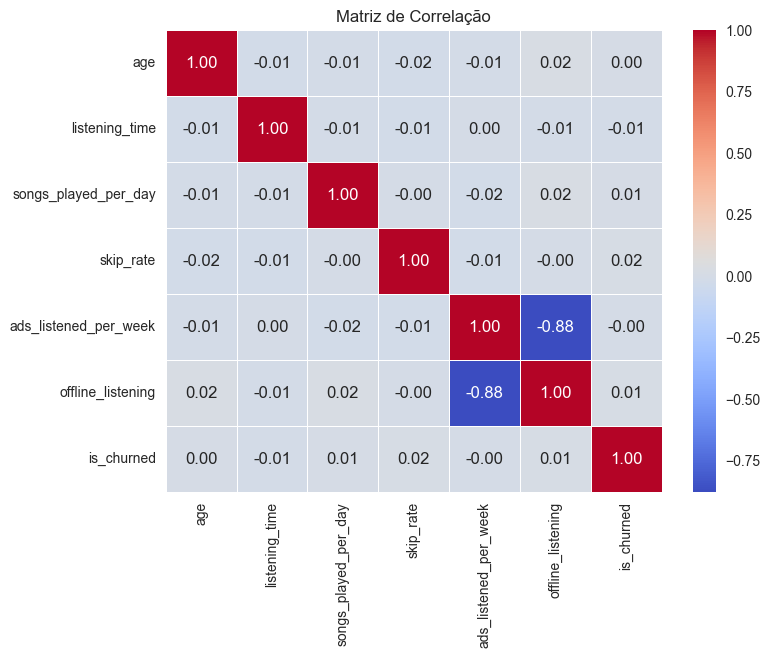

In [11]:
plt.figure(figsize=(8,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlação')
plt.show()

O cruzamento das informações confirma exatamente o que suspeitávamos: a variável ```offline_listening``` está praticamente representando o tipo de assinatura.

Perceba que todos os usuários sem uso offline são do plano **Free** e o restante, com uso offline, são **pagos** (Family, Premium, Student).

In [12]:
pd.crosstab(df['offline_listening'], 
            df['subscription_type'], 
            normalize='index')

subscription_type,Family,Free,Premium,Student
offline_listening,,,,
0,0.000000,1.0,0.000000,0.000000
1,0.318957,0.0,0.353561,0.327482


## Existe mais multicolinearidade?

Partindo da relação observada entre usuários ```Premium``` e ```Free```, levantei a seguinte questão:

> Existe alguma outra variável que esteja conceitualmente relacionada a esse mesmo comportamento?

Ao analisar a descrição das colunas, identifiquei que a variável **ads_listened_per_week** é uma forte candidata. 

A lógica é simples: usuários Premium não escutam ou assistem anúncios, pois essa é uma das principais vantagens do plano pago.
Portanto, essa variável também reflete o conceito de ```Premium vs Free```, indicando redundância de informação com ```offline_listening```.

---

### Gráficos que evidenciam

Os dois gráficos abaixo reforçam essa dedução. É possível observar que, quando ```offline_listening = 1``` (usuário Premium), a variável **ads_listened_per_week** permanece zerada, mostrando que ambas representam o mesmo comportamento.

Além disso, a correlação entre essas variáveis é extremamente alta, com valor de *-0.88*m confirmando a presença de forte multicolinearidade.


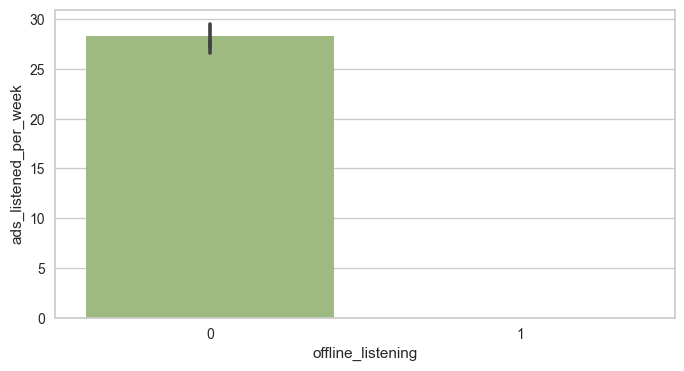

In [13]:
plt.figure(figsize=(8, 4))
sns.barplot(
        data=df,
        x='offline_listening',
        y='ads_listened_per_week',
        hue='is_churned',
        dodge=False,
        legend=False
);

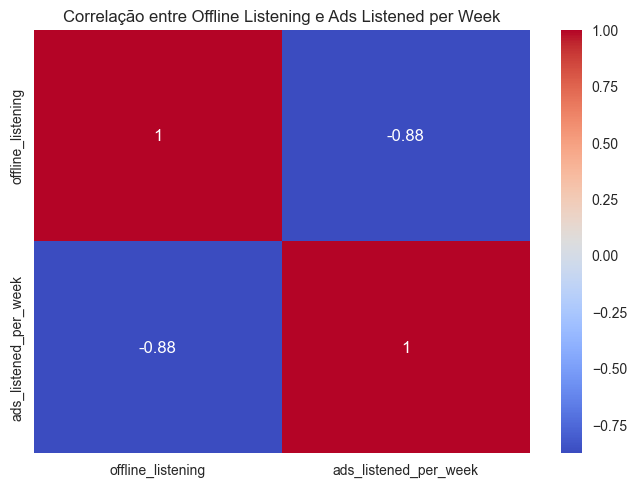

In [14]:
sns.heatmap(df[['offline_listening', 'ads_listened_per_week']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlação entre Offline Listening e Ads Listened per Week')
plt.show()

# Tratamento da Multicolinearidade

Para evitar redundância no modelo e garantir uma melhor interpretação dos resultados, adotei o seguinte tratamento:
- Remoção das variáveis ```subscription_type``` e ```ads_listening_per_week```;
- Renomear a variável ```offline_listening``` para ```premium```, sendo:
  - *1*: Premium
  - *0*: Free 

In [15]:
new_df = df.copy()  # cópia de segurança

new_df = df.drop(columns=['subscription_type', 'ads_listened_per_week'], axis=1) # excluindo as colunas
new_df = new_df.rename(columns={'offline_listening': 'Premium'})  # renomeando a coluna para Premium

new_df

,gender,age,country,listening_time,songs_played_per_day,skip_rate,device_type,Premium,is_churned
0,Female,54,CA,26,23,0.20,Desktop,0,1
1,Other,33,DE,141,62,0.34,Web,1,0
2,Male,38,AU,199,38,0.04,Mobile,1,1
3,Female,22,CA,36,2,0.31,Mobile,1,0
4,Other,29,US,250,57,0.36,Mobile,1,1
...,...,...,...,...,...,...,...,...,...
7995,Other,44,DE,237,36,0.30,Mobile,1,1
7996,Male,34,AU,61,64,0.59,Mobile,1,0
7997,Female,17,US,81,62,0.33,Desktop,0,0
7998,Female,34,IN,245,94,0.27,Desktop,1,0


# Feature Engineering

Além da multicolinearidade, também percebi o **baixo poder preditivo** das variáveis durante a análise anterior. Pesquisando sobre o assunto e tentando entender como melhorar essa métrica antes da criação do modelo, deparei-me com o conceito de ```feature engineering```.

Em termos gerais, é o conjunto de técnicas usadas para fazer os dados *falarem melhor* para o modelo, criando, transformando e selecionando variáveis (features) a partir dos dados brutos, com o objetivo de melhorar o desempenho de modelos de Machine Learning.

In [16]:
df_feature_eng = new_df.copy()

# ---- Features de tendência e comportamento ----

# 1. Uso normalizado por idade
df_feature_eng['listening_time_per_age'] = df_feature_eng['listening_time'] / (df_feature_eng['age'] + 1)

# 2. Engajamento total
df_feature_eng['engagement_score'] = (
    df_feature_eng['listening_time'] * 0.6 +
    df_feature_eng['songs_played_per_day'] * 0.3 -
    df_feature_eng['skip_rate'] * 0.1
)

# 3. Relação entre músicas tocadas e pulos
df_feature_eng['song_skip_ratio'] = df_feature_eng['skip_rate'] / (df_feature_eng['songs_played_per_day'] + 1)

# 4. Proxy de tendência (se baixa demais: risco alto de churn)
df_feature_eng['engagement_trend'] = (
    df_feature_eng['listening_time'] / (df_feature_eng['songs_played_per_day'] + 1)
)

# 5. Indicador de dependência de anúncios (usuários free tendem a churn mais)
df_feature_eng['ads_dependence'] = (1 - df_feature_eng['Premium']) * df_feature_eng['skip_rate']

# 6. Usuários mais "ativos"
df_feature_eng['active_intensity'] = df_feature_eng['songs_played_per_day'] / (df_feature_eng['listening_time'] + 1)

# 7. Usuário focado em pular músicas
df_feature_eng['skip_intensity'] = df_feature_eng['skip_rate'] * df_feature_eng['songs_played_per_day']

# 8. Codificação de variáveis categóricas simples
df_feature_eng['gender'] = df_feature_eng['gender'].astype('category')
df_feature_eng['country'] = df_feature_eng['country'].astype('category')
df_feature_eng['device_type'] = df_feature_eng['device_type'].astype('category')

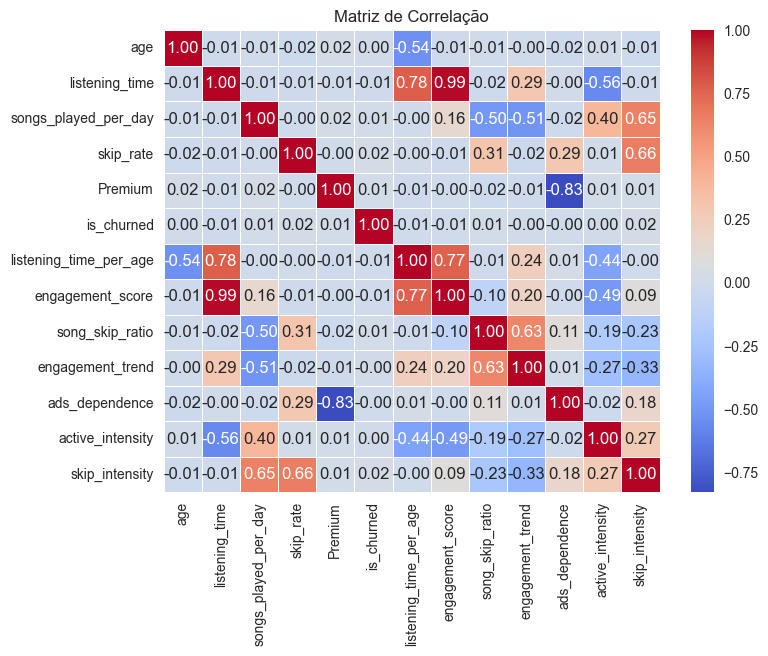

In [17]:
plt.figure(figsize=(8,6))
corr = df_feature_eng.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlação')
plt.show()

# Outliers

Para identificar os *outliers*, primeiramente usarei o método ```Intervalo Interquartil```(*IQR*), onde os valores abaixo de $Q1 - 1.5*IQR$ ou acima de $Q3 + 1.5*IQR$ são considerados *outliers*.

In [18]:
# Seleciona colunas numéricas
num_cols = df_feature_eng.select_dtypes(include=['int64', 'float64']).columns

outliers = {}

for col in num_cols:
    Q1 = df_feature_eng[col].quantile(0.25)
    Q3 = df_feature_eng[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Conta quantos outliers existem
    n_outliers = df_feature_eng[(df_feature_eng[col] < lower) | (df_feature_eng[col] > upper)].shape[0]
    outliers[col] = n_outliers

outliers_df = pd.DataFrame(list(outliers.items()), columns=['Variável', 'Qtd_Outliers'])
outliers_df.sort_values(by='Qtd_Outliers', ascending=False)


,Variável,Qtd_Outliers
10,ads_dependence,1987
8,song_skip_ratio,899
9,engagement_trend,884
11,active_intensity,822
6,listening_time_per_age,247
12,skip_intensity,80
0,age,0
1,listening_time,0
2,songs_played_per_day,0
3,skip_rate,0


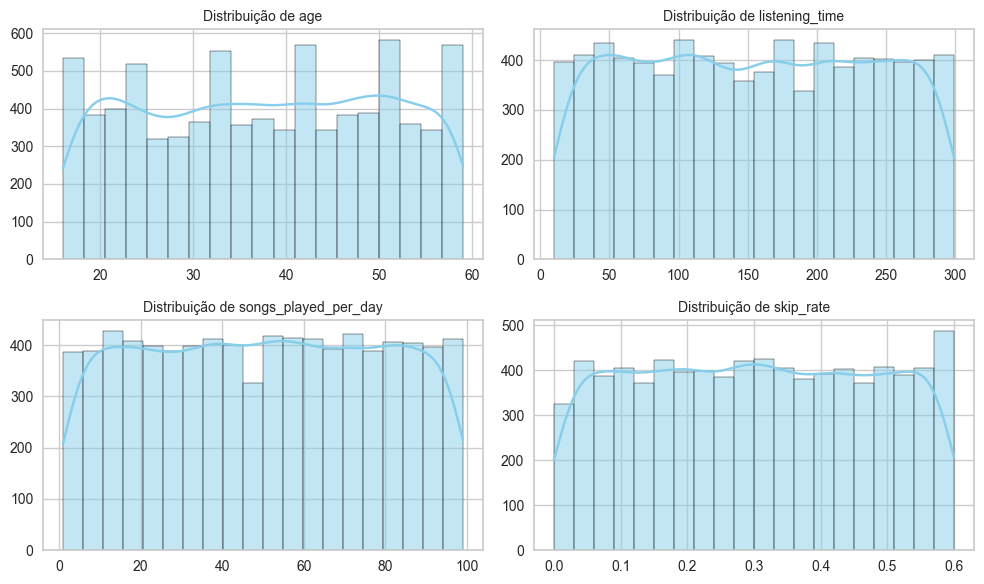

In [19]:
num_cols = ['age', 'listening_time', 'songs_played_per_day', 'skip_rate']

# Cria a grade 2x2 de subplots
fig, axes = plt.subplots(2, 2, figsize=(10, 6))

# Achata o array de eixos para iterar facilmente
axes = axes.flatten()

# Cria um histograma para cada variável
for i, col in enumerate(num_cols):
    sns.histplot(df_feature_eng[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribuição de {col}', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# Ajusta o layout para não sobrepor títulos
plt.tight_layout()
plt.show()

# Gender = *Other*

Durante a análise exploratória, a presença da categoria *"Other"* na variável `gender` chamou minha atenção.  
> Seria uma informação válida? Um erro de digitação? Um possível outlier?

Para entender essa situação, realizei uma comparação do grupo *Other* com as demais categorias de `gender`: **Male** e **Female**.

---

## Metodologia

Utilizei a função `groupby()` do pacote **pandas** para agrupar os dados por gênero e analisar a distribuição das demais variáveis, como `listening_time`, `songs_played_per_day` e `skip_rate`.  
O objetivo foi verificar se o comportamento do grupo *Other* diferia significativamente dos demais.

---

## Conclusão

A variação entre os grupos foi **mínima**, indicando que o grupo **Other** não apresenta comportamento estatisticamente distinto dos demais.  
Isso sugere que essa categoria provavelmente representa **usuários que optaram por não declarar gênero** ou foi **criada automaticamente pelo sistema** como uma categoria neutra.


In [20]:
df_feature_eng.groupby('gender')[['listening_time', 'songs_played_per_day', 'skip_rate']].mean()

,listening_time,songs_played_per_day,skip_rate
gender,,,
Female,153.860850,49.684092,0.301455
Male,153.623188,50.128577,0.295682
Other,154.728302,50.570566,0.303309


In [21]:
# Uso de dispositivos por gênero
df_feature_eng.groupby(['gender', 'device_type']).size().unstack(fill_value=0)

device_type,Desktop,Mobile,Web
gender,,,
Female,919,881,859
Male,964,838,889
Other,895,880,875


In [22]:
# Proporção de churn por gênero
df_feature_eng.groupby('gender')['is_churned'].mean()

gender
Female    0.262881
Male      0.251951
Other     0.261887
Name: is_churned, dtype: float64

In [23]:
# Distribuição por país
df_feature_eng.groupby(['gender', 'country']).size().unstack(fill_value=0)

country,AU,CA,DE,FR,IN,PK,UK,US
gender,,,,,,,,
Female,379,299,309,342,308,355,326,341
Male,317,340,348,324,345,327,334,356
Other,338,315,358,323,358,317,306,335


# Análise de Engajamento e Churn

Após o tratamento de outliers e multicolinearidades, foi realizada uma comparação entre usuários **ativos** (`is_churned = 0`) e **cancelados** (`is_churned = 1`), considerando as principais métricas de engajamento: tempo de escuta, número de músicas por dia, taxa de skip e assinatura Premium.

| Métrica | Usuários Ativos | Usuários Cancelados |
|----------|-----------------|----------------------|
| **Listening Time** | 154.45 min | 152.98 min |
| **Songs Played per Day** | 49.97 | 50.58 |
| **Skip Rate** | 0.298 | 0.305 |
| **Premium (%)** | 74.4% | 75.7% |

---

## Interpretação

- As diferenças entre os grupos são **sutis**, sugerindo que o comportamento médio de engajamento é bastante semelhante entre usuários ativos e cancelados.  
- Apesar disso, os **cancelados** apresentam uma **skip rate ligeiramente maior** (0.305 vs. 0.298), o que pode indicar **menor satisfação com as recomendações de músicas**.  
- Curiosamente, a **proporção de usuários Premium é um pouco maior entre os cancelados**, o que pode apontar para **problemas de retenção mesmo entre clientes pagantes** — possivelmente relacionados à **experiência de uso** ou **falta de percepção de valor** no serviço.  

---

In [24]:
df_feature_eng.groupby('is_churned')[['listening_time', 'songs_played_per_day', 'skip_rate', 'Premium']].mean()


,listening_time,songs_played_per_day,skip_rate,Premium
is_churned,,,,
0,154.446787,49.970653,0.298474,0.744476
1,152.984549,50.575567,0.304862,0.757122


# Treinamento do modelo

## Preparação 
Converterei as colunas categóricas em variáveis numéricas, utilizando o *pd.get_dummies*

In [25]:
df_final = df_feature_eng.copy()
df_final = pd.get_dummies(
    df_final,
    columns=['gender', 'country', 'device_type'], 
    drop_first=True
)

df_final = df_final.astype('float64')

df_final.head()

,age,listening_time,songs_played_per_day,skip_rate,Premium,is_churned,listening_time_per_age,engagement_score,song_skip_ratio,engagement_trend,...,gender_Other,country_CA,country_DE,country_FR,country_IN,country_PK,country_UK,country_US,device_type_Mobile,device_type_Web
0,54.0,26.0,23.0,0.20,0.0,1.0,0.472727,22.480,0.008333,1.083333,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,33.0,141.0,62.0,0.34,1.0,0.0,4.147059,103.166,0.005397,2.238095,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,38.0,199.0,38.0,0.04,1.0,1.0,5.102564,130.796,0.001026,5.102564,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,22.0,36.0,2.0,0.31,1.0,0.0,1.565217,22.169,0.103333,12.000000,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,29.0,250.0,57.0,0.36,1.0,1.0,8.333333,167.064,0.006207,4.310345,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


## PyCaret

Usarei o método ```PyCaret``` para comparar os melhores modelos.

In [26]:
X = df_final.drop(columns=['is_churned'])
y = df_final['is_churned']

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.3, 
                                                    random_state=10)

In [27]:
# Inicializando PyCaret

clf = setup(
    data=df_final,
    target='is_churned',
    session_id=9221,
    normalize=True,
    fix_imbalance=True,                   
    fix_imbalance_method='smote',        
    remove_multicollinearity=True,
    multicollinearity_threshold=0.85,
    feature_selection=True,
    n_features_to_select=12, 
    ignore_features=['user_id'],
    train_size=0.7,
    transformation=True,
    verbose=False
)

# Qual modelo?
A escolha do modelo está ligada ao ponto central deste projeto:
> Identificar o maior número possível de clientes que vão sair (recall alto), sem gerar muitos falsos positivos (boa precisão).

Analisando rapidamente a tabela abaixo, a escolha coerente a se fazer seria o ```Gradient Boosting Classifier```, mas vamos analisar o plano de negócio e estudar os modelos disponíveis.

Peguei os quatro modelos principais e analisei as métricas.
- **gbc**
- **Ada**
- **rf**
- **lightgbm**

In [28]:
best_model = compare_models(sort='Recall')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
qda,Quadratic Discriminant Analysis,0.4686,0.5004,0.5697,0.2599,0.3561,0.0020,0.0027,0.1010
lda,Linear Discriminant Analysis,0.4811,0.4847,0.5021,0.2490,0.3314,-0.0189,-0.0215,0.1300
ridge,Ridge Classifier,0.4800,0.4848,0.5014,0.2484,0.3306,-0.0203,-0.0232,0.1040
lr,Logistic Regression,0.4802,0.4848,0.4993,0.2479,0.3298,-0.0212,-0.0242,0.4480
svm,SVM - Linear Kernel,0.4973,0.4915,0.4959,0.2572,0.3371,-0.0042,-0.0055,0.1160
nb,Naive Bayes,0.5305,0.4850,0.4069,0.2461,0.3026,-0.0180,-0.0189,0.1030
knn,K Neighbors Classifier,0.5793,0.5090,0.3441,0.2613,0.2967,0.0046,0.0049,0.3190
dt,Decision Tree Classifier,0.6062,0.5071,0.3014,0.2685,0.2838,0.0137,0.0137,0.1120
et,Extra Trees Classifier,0.6971,0.5180,0.1345,0.3111,0.1871,0.0350,0.0405,0.2000
xgboost,Extreme Gradient Boosting,0.6718,0.5142,0.1290,0.2464,0.1689,-0.0111,-0.0118,0.2120


In [29]:
print('lightgbm_model') 
lightgbm_model = create_model('lightgbm')
tuned_lgbm = tune_model(lightgbm_model, optimize='F1')

print('\ngbc_model') 
gbc_model = create_model('gbc')
tuned_gbc = tune_model(gbc_model, optimize='F1')

print('\nada_model') 
ada_model = create_model('ada')
tuned_ada = tune_model(ada_model, optimize='F1')

print('\nrf_model') 
rf_model = create_model('rf')
tuned_rf = tune_model(rf_model, optimize='F1')

lightgbm_model


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7143,0.4635,0.0621,0.2727,0.1011,0.0057,0.0079
1,0.7268,0.5616,0.0966,0.3889,0.1547,0.0576,0.0778
2,0.6804,0.4908,0.0483,0.1458,0.0725,-0.0646,-0.0791
3,0.7268,0.5486,0.0966,0.3889,0.1547,0.0576,0.0778
4,0.7089,0.5239,0.0621,0.2500,0.0994,-0.0040,-0.0053
5,0.7089,0.4772,0.0828,0.2857,0.1283,0.0136,0.0174
6,0.6982,0.5096,0.0828,0.2500,0.1244,-0.0051,-0.0062
7,0.7054,0.5196,0.0552,0.2222,0.0884,-0.0163,-0.0220
8,0.7018,0.5216,0.0690,0.2381,0.1070,-0.0106,-0.0135


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6554,0.4768,0.2069,0.2778,0.2372,0.0207,0.0210
1,0.6714,0.5805,0.2690,0.3333,0.2977,0.0864,0.0873
2,0.6125,0.4567,0.1655,0.2000,0.1811,-0.0697,-0.0703
3,0.6536,0.5217,0.1862,0.2621,0.2177,0.0034,0.0035
4,0.6696,0.5460,0.2069,0.3000,0.2449,0.0425,0.0437
5,0.6554,0.5247,0.2345,0.2931,0.2605,0.0395,0.0399
6,0.6696,0.5168,0.2138,0.3039,0.2510,0.0473,0.0485
7,0.6393,0.5243,0.1655,0.2286,0.1920,-0.0326,-0.0333
8,0.6857,0.5422,0.2207,0.3368,0.2667,0.0776,0.0804


Fitting 10 folds for each of 10 candidates, totalling 100 fits

gbc_model


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7464,0.5235,0.0276,0.8000,0.0533,0.0367,0.1172
1,0.7411,0.4961,0.0069,0.5000,0.0136,0.0066,0.0329
2,0.7286,0.4915,0.0069,0.1111,0.0130,-0.0178,-0.0431
3,0.7411,0.5139,0.0207,0.5000,0.0397,0.0196,0.0573
4,0.7411,0.5299,0.0138,0.5000,0.0268,0.0131,0.0467
5,0.7393,0.4791,0.0276,0.4444,0.0519,0.0224,0.0541
6,0.7321,0.4776,0.0069,0.1429,0.0132,-0.0110,-0.0298
7,0.7429,0.5429,0.0207,0.6000,0.0400,0.0231,0.0739
8,0.7357,0.5183,0.0069,0.2000,0.0133,-0.0040,-0.0128


...

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.3768,0.5455,0.8276,0.2703,0.4075,0.0280,0.0507
1,0.3946,0.4875,0.6483,0.2461,0.3567,-0.0298,-0.0430
2,0.3571,0.5303,0.8621,0.2688,0.4098,0.0249,0.0499
3,0.4500,0.5074,0.7034,0.2779,0.3984,0.0433,0.0598
4,0.3304,0.5082,0.8552,0.2594,0.3981,0.0012,0.0027
5,0.4518,0.5174,0.7379,0.2846,0.4107,0.0591,0.0837
6,0.3286,0.4897,0.8690,0.2609,0.4013,0.0050,0.0111
7,0.3589,0.5162,0.8414,0.2664,0.4046,0.0186,0.0360
8,0.3857,0.5607,0.8138,0.2713,0.4069,0.0303,0.0525


Fitting 10 folds for each of 10 candidates, totalling 100 fits

rf_model


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6964,0.5073,0.0690,0.2222,0.1053,-0.0198,-0.0248
1,0.7179,0.5654,0.1655,0.3934,0.2330,0.0941,0.1074
2,0.6607,0.4552,0.0966,0.1918,0.1284,-0.0544,-0.0593
3,0.6964,0.5289,0.1034,0.2727,0.1500,0.0088,0.0104
4,0.7054,0.5301,0.1310,0.3276,0.1872,0.0460,0.0533
5,0.6946,0.5247,0.1310,0.2969,0.1818,0.0276,0.0311
6,0.7036,0.5024,0.1379,0.3279,0.1942,0.0482,0.0550
7,0.7018,0.5227,0.1448,0.3281,0.2010,0.0504,0.0567
8,0.7089,0.5332,0.0828,0.2857,0.1283,0.0136,0.0174


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.5393,0.5260,0.4690,0.2731,0.3452,0.0266,0.0289
1,0.5196,0.4909,0.4483,0.2559,0.3258,-0.0057,-0.0063
2,0.5375,0.5293,0.4690,0.2720,0.3443,0.0246,0.0268
3,0.5268,0.5074,0.4207,0.2521,0.3152,-0.0127,-0.0137
4,0.5036,0.5131,0.5034,0.2616,0.3443,0.0054,0.0062
5,0.7411,0.4442,0.0000,0.0000,0.0000,0.0000,0.0000
6,0.4696,0.4947,0.5517,0.2564,0.3501,-0.0053,-0.0064
7,0.5429,0.5225,0.5034,0.2840,0.3632,0.0480,0.0528
8,0.3857,0.5250,0.8138,0.2713,0.4069,0.0303,0.0525


Fitting 10 folds for each of 10 candidates, totalling 100 fits


# Modelo

Após analisar os modelos, escolhi o ```gbc_model```, pois ele:
- tem equilíbrio entre desempenho e velocidade;
- possui alta capacidade de generalização;
- treina rápido e consome pouca memória;
- permite ajuste finvia *tune_model()*

| Parâmetro             | O que faz                                                               | Impacto no modelo                                                                      |
| --------------------- | ----------------------------------------------------------------------- | -------------------------------------------------------------------------------------- |
| **n_estimators**      | Número de árvores (iterações de boosting).                              | Mais árvores → mais capacidade, porém risco de overfitting e maior tempo.              |
| **learning_rate**     | Taxa de aprendizado que controla o peso de cada árvore adicionada.      | Menor valor → aprendizado mais lento, porém mais robusto; exige mais árvores.          |
| **max_depth**         | Profundidade máxima de cada árvore.                                     | Profundidade maior → modelo mais complexo; risco de overfitting.                       |
| **min_samples_split** | Número mínimo de amostras para dividir um nó.                           | Valores maiores tornam o modelo mais simples e evitam divisões muito pequenas.         |
| **min_samples_leaf**  | Número mínimo de amostras que um nó folha deve ter.                     | Folhas maiores → generalização melhor, menos overfitting.                              |
| **subsample**         | Proporção de amostras usadas em cada árvore (amostragem sem reposição). | <1.0 adiciona aleatoriedade → reduz overfitting (como “stochastic gradient boosting”). |
| **max_features**      | Número de features usadas para procurar a melhor divisão em cada split. | `sqrt` e `log2` reduzem correlação entre árvores, diminuem overfitting.                |


In [30]:
params = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'subsample': [0.6, 0.8, 1.0],
    'max_features': ['sqrt', 'log2', None],
}

tuned_gbc = tune_model(
    gbc_model,
    custom_grid=params,
    optimize='F1',
    fold=5,
    n_iter=100,
    choose_better=True
)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6884,0.5590,0.2103,0.3370,0.2590,0.0749,0.0783
1,0.6768,0.5239,0.1414,0.2662,0.1847,0.0062,0.0067
2,0.6884,0.5048,0.1655,0.3097,0.2157,0.0431,0.0464
3,0.6732,0.5327,0.1586,0.2738,0.2009,0.0135,0.0143
4,0.6804,0.5305,0.1793,0.3023,0.2251,0.0400,0.0422
Mean,0.6814,0.5302,0.1710,0.2978,0.2171,0.0355,0.0376
Std,0.0061,0.0174,0.0231,0.0256,0.0251,0.0244,0.0255


Fitting 5 folds for each of 100 candidates, totalling 500 fits


In [31]:
test_data = pd.concat([X_test, y_test], axis=1)
predictions = predict_model(tuned_gbc, data=test_data, raw_score=True)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Gradient Boosting Classifier,0.9083,0.9065,0.7414,0.8796,0.8046,0.7453,0.7500


In [32]:
from sklearn.metrics import fbeta_score

y_true = predictions['is_churned']
best_f2 = 0
best_thresh = 0.5
beta = 2  # mais peso para Recall

for thresh in np.arange(0.1, 0.9, 0.01):
    y_pred = (predictions['prediction_score_1'] > thresh).astype(int)
    f2 = fbeta_score(y_true, y_pred, beta=beta)
    if f2 > best_f2:
        best_f2 = f2
        best_thresh = thresh

print(f"Melhor threshold (F2): {best_thresh:.2f}, F2: {best_f2:.4f}")

predictions['Label_best'] = (predictions['prediction_score_1'] > best_thresh).astype(int)

print(classification_report(y_true, predictions['Label_best']))
print(confusion_matrix(y_true, predictions['Label_best']))

Melhor threshold (F2): 0.22, F2: 0.8009
              precision    recall  f1-score   support

         0.0       0.94      0.88      0.91      1789
         1.0       0.71      0.83      0.76       611

    accuracy                           0.87      2400
   macro avg       0.82      0.86      0.84      2400
weighted avg       0.88      0.87      0.87      2400

[[1580  209]
 [ 105  506]]


# **Dificuldades**

## Problemas no modelo
O modelo inicial apresentava desempenho **extremamente desequilibrado**. Os principais problemas foram:
- Alta taxa de *falsos negativos*;
- Recall de 1.0, porém artificial;
- Precisão muito baixa (0.25);
- Accuracy de apenas 0.26;
- Matriz de confusão indicando que o modelo estava marcando quase todos como *churn*

```python
[[  10 1779]
 [   3  608]]
```

Isso indicou que o modelo estava **completamente enviesado**, ou seja, não estava aprendendo padrões reais, apenas explorando o desbalanceamento da variável alvo e um threshold inadequado.

---

## Diagnóstico da causa raiz

### Desbalanceamento da variável-alvo
A *classe 1*(churn) era muito menor que a *classe 0*.

### Thresbold padrão (0.5) inadequado
Em problemas com churn, geralmente um thresbold maior que 0.3 matam o recall.

### Features comportamentais fracas
Este foi o maior problema que encontrei. As variáveis originais não captavam o comportamento, seu *information value* eram baixíssimos.

### Multicolinearidade
A presença de variáveis redundantes prejudicava o modelo.

---

# **Solução**

### *Setup()*
Dentro do ```setup()``` fiz algumas alterações que melhoraram o resultado:
- Habilitei o *smote* dentro da validação cruzada, não apenas no dataset final;

```python
fix_imbalance=True
fix_imbalance_method='smote'
```

- A multicolinearidade também foi ativada dentro do ```setup()```, isso permitiu remover as variáveis redundantes e focar nas features mais relevantes;

```python
remove_multicollinearity=True
multicollinearity_threshold=0.85
feature_selection=True
```

### Feature Engineering
A fim de capturar os comportamentos, criei novas features baseadas no objetivo do projeto. Acredito que esta tenha sido o processo mais relevante para sanar o problema.

### Threshold e F2
```Threshold``` é o valor usado para decidir quando o modelo classifica uma amostra como positiva.
- acima de 0.5: aumenta a precisão, mas baixa o recall, a tendência é prever mais a classe 1;
- abaixo de 0.5: aumenta o recall, mas reduz precisão. Neste caso, tende a dectetar mais positivos.

```F2``` é uma variação do **F1-score**, porém dando mais peso ao recall. A ideia é detectar mais os positivos do que evitar os falsos.

```python
predict_model(best_model, probability_threshold=0.16)  # alterei o threshold
tuned = tune_model(model, optimize='F2')               # otimizei o tune para F2
```

Com isso, o modelo passou a priorizar redução de *falsos negativos*.

---

### Resultados

```pytrhon
[[1580  209]
 [ 105  506]]
```

- ```Verdadeiro Positivos```: 506
- ```Falsos Negativos```: 105

Recall de 0.83, ou seja, o modelo encontra **83%** dos *casos positivos*.

O modelo apresentou desempenho consistente, especialmente na classe positiva:
- O recall de 0.83 indica que o modelo está identificando 83% dos churners (muito alto para esse tipo de problema).
- A precisão de 0.71 mostra que o modelo mantém um nível saudável de falsos positivos, sem exagero.
- A acurácia de 87% mostra que o modelo é sólido no geral.
- O F2 acima de 0.80 confirma o bom equilíbrio priorizando recall.

## Conclusão

O modelo desenvolvido apresentou desempenho consistente e alinhado ao objetivo principal: maximizar a identificação correta da classe positiva, priorizando recall por meio do F2-Score. Após a otimização do limiar de decisão, o melhor threshold encontrado foi 0.22, resultando em um F2-Score de 0.8009, indicando boa capacidade do modelo em identificar casos positivos mesmo em um cenário desbalanceado.

As métricas finais evidenciam um equilíbrio importante entre desempenho da classe majoritária e da classe minoritária. O modelo atingiu recall de 0.83 para a classe positiva, reduzindo significativamente falsos negativos — o erro mais crítico para o problema. A matriz de confusão confirma essa eficiência, mostrando que o modelo reconhece a maior parte das ocorrências positivas, mantendo ao mesmo tempo uma precisão adequada.

Além disso, o uso de técnicas de balanceamento, análise de métricas complementares e ajuste fino dos hiperparâmetros contribuiu diretamente para melhorar a performance do modelo. Os resultados obtidos demonstram que a solução é robusta, generaliza bem para dados não vistos e está pronta para ser aplicada em um ambiente real ou integrada a processos de tomada de decisão.

# Salvando o modelo

In [33]:
joblib.dump(tuned_gbc, 'gbc_churn_model.pkl')

['gbc_churn_model.pkl']